# Import Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import dates as md
import time
import re, fileinput, sys, pathlib, os
from itertools import cycle
import numpy as np

In [2]:
def parsefile(file):
    throughput_pattern = re.compile(r'\[OVERALL\], Throughput\(ops/sec\), (\d+.?\d*)')
    read_num_pattern = re.compile(r'\[READ\], Total Operations, (\d+)')
    read_ok_pattern = re.compile(r'\[READ\], Return=OK, (\d+)')
    read_pattern = re.compile(r'\[READ\], ([A-Za-z]+|p\d+\.?\d*), (\d+)')
    update_pattern = re.compile(r'\[UPDATE\], ([A-Za-z]+|p\d+\.?\d*), (\d+)')
    update_num_pattern = re.compile(r'\[UPDATE\], Total Operations, (\d+)')
    update_ok_pattern = re.compile(r'\[UPDATE\], Return=OK, (\d+)')
    runtimep = re.compile(r'\[OVERALL\], RunTime\(ms\), (\d+)')
    throughput = 'not_found'
    read_num = 'not_found'
    read_ok = 'not_found'
    read = {}
    update_num = 'not_found'
    update_ok = 'not_found'
    update = {}

    result = {}
    
    with open(file) as f:
        for line in f:
            m = runtimep.search(line)
            if m:
                result = result | {'runtime(ms)': m.group(1)}
            m = throughput_pattern.search(line)
            if m:
                throughput = m.group(1)
            m = read_num_pattern.search(line)
            if m:
                read_num = m.group(1)
            m = read_ok_pattern.search(line)
            if m:
                read_ok = m.group(1)
            m = read_pattern.search(line)
            if m:
                label = f'read_{m.group(1).lower()}(us)'
                read = read | {label: m.group(2)}
            m = update_num_pattern.search(line)
            if m:
                update_num = m.group(1)
            m = update_ok_pattern.search(line)
            if m:
                update_ok = m.group(1)
            m = update_pattern.search(line)
            if m:
                label = f'update_{m.group(1).lower()}(us)'
                update = update | {label: m.group(2)}
    return result | {'throughput(ops/s)': [throughput], 'read_num': [read_num], 'read_ok': [read_ok], 'update_num': [update_num], 'update_ok': [update_ok]} | read | update

In [3]:
df = pd.DataFrame()
workloadp = re.compile(r'workload[a-z]|writeonly|readonly')
nodesp = re.compile(r'(\d+)nodes')
threadsp = re.compile(r'(\d+)threads')
targetp = re.compile(r'([0-9a-z]+)target')
operationsp = re.compile(r'(\d+)operations')
recordsp = re.compile(r'(\d+)records')
timeoutp = re.compile(r'(\d+)timeout')
batchsizep = re.compile(r'(\d+)batchsize')
kill_leaderp = re.compile(r'(\d+)kill_leader')
timep = re.compile(r'\d+-\d+-\d+-\d+:\d+:\d+')
geo_replp = re.compile(r'geo-repl')
single_conp = re.compile(r'single-con')
historyp = re.compile(r'history([A-Za-z]+\d*)')
commitreadsp = re.compile(r'commitreads([A-Za-z]+)')
twconnp = re.compile(r'twoWayConnections')
smallrepp = re.compile(r'smallReplies')
futurep = re.compile(r'future')
atomicp = re.compile(r'atomic-refs')
testp = re.compile(r'simple-test')
for kind in ['pb', 'etcd']:
    for fileObj in os.scandir("../results/raw/"+kind):
        file = fileObj.name
        workload = workloadp.search(file).group()
        nodes = nodesp.search(file).group(1)
        threads = threadsp.search(file).group(1)
        target = targetp.search(file).group(1)
        time = timep.search(file).group(0)
        m = commitreadsp.search(file)
        if m:
            commitreads = m.group(1).lower()
        else:
            commitreads = 'undefined'
        m = operationsp.search(file)
        if m:
            operations = m.group(1)
        else:
            operations = 'undefined'
        m = recordsp.search(file)
        if m:
            records = m.group(1)
        else:
            records = 'undefined'
        m = timeoutp.search(file)
        if m:
            timeout = m.group(1)
        else:
            timeout = 'undefined'
        m = batchsizep.search(file)
        if m:
            batchsize = m.group(1)
        else:
            batchsize = 'undefined'
        m = kill_leaderp.search(file)
        if m:
            kill_leader = m.group(1)
        else:
            kill_leader = 'undefined'
        m = geo_replp.search(file)
        if m:
            geo_repl = True
        else:
            geo_repl = False
        m = single_conp.search(file)
        if m:
            single_con = True
        else:
            single_con = False
        m = historyp.search(file)
        if m:
            history = m.group(1).lower()
        else:
            history = 'undefined'
        m = twconnp.search(file)
        if m:
            twconn = True
        else:
            twconn = 'undefined'
        m = smallrepp.search(file)
        if m:
            smallrep = True
        else:
            smallrep = 'undefined'
        m = futurep.search(file)
        if m:
            future = True
        else:
            future = 'undefined'
        m = atomicp.search(file)
        if m:
            atomic = True
        else:
            atomic = 'undefined'
        m = testp.search(file)
        if m:
            test = True
        else:
            test = 'undefined'
    
        header_data = {'system': [kind], 'small_replies': [smallrep], 'simple_test': [test], 'future': [future], 'atomic_refs': [atomic], 'single_con': [single_con], 'tw_conn': [twconn], 'geo_repl': [geo_repl], 'time': [time], 'workload': [workload], 'nodes': [nodes], 'threads': [threads], 'target': [target], 'operations': [operations], 'records': [records], 'timeout': [timeout], 'batchsize': [batchsize], 'kill_leader': [kill_leader], 'history': [history], 'filename': [file], 'commit_reads': [commitreads]}
        in_file_data = parsefile(fileObj.path)
        new_row = pd.DataFrame(header_data | in_file_data)
        df = pd.concat([df,new_row])
    

In [4]:
# clean up df and change datatypes
df = df[df['throughput(ops/s)'] != 'not_found']
df['time'] = pd.to_datetime(df['time'])
df = df.astype({'nodes': 'int32', 'threads': 'int32', 'throughput(ops/s)': 'float64', 'read_p90(us)': 'Int64', 'update_p90(us)': 'Int64', 'update_p99(us)': 'Int64', 'update_average(us)': 'Int64', 'read_p99(us)': 'Int64', 'read_average(us)': 'Int64', 'runtime(ms)': 'int64', 'timeout': 'int64'})
df['update_p99(ms)'] = df['update_p99(us)'] / 1000
df['update_p90(ms)'] = df['update_p90(us)'] / 1000
df['update_average(ms)'] = df['update_average(us)'] / 1000
df['read_p99(ms)'] = df['read_p99(us)'] / 1000
df['read_p90(ms)'] = df['read_p90(us)'] / 1000
df['read_average(ms)'] = df['read_average(us)'] / 1000
df['runtime(s)'] = df['runtime(ms)'] / 1000
df = df.round({"runtime(s)": 0})
df['runtime(s)'] = df['runtime(s)'].astype(int)
#df['read_p99(ms)'] = df['read_p99(us)'] / 1000
df = df.reset_index()
df.drop('index', axis=1)

,system,small_replies,simple_test,future,atomic_refs,single_con,tw_conn,geo_repl,time,workload,...,read_p99(us),read_p99.9(us),read_p99.99(us),update_p99(ms),update_p90(ms),update_average(ms),read_p99(ms),read_p90(ms),read_average(ms),runtime(s)
0,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 06:30:51,writeonly,...,<NA>,NaN,NaN,183.929,131.838,111.979,<NA>,<NA>,<NA>,56
1,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 05:30:30,writeonly,...,<NA>,NaN,NaN,175.181,125.218,109.855,<NA>,<NA>,<NA>,55
2,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 06:29:00,writeonly,...,<NA>,NaN,NaN,102.104,65.102,56.073,<NA>,<NA>,<NA>,56
3,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 13:45:17,writeonly,...,<NA>,NaN,NaN,94.971,57.343,49.29,<NA>,<NA>,<NA>,49
4,pb,undefined,undefined,undefined,True,True,undefined,False,2026-03-11 12:17:47,writeonly,...,<NA>,NaN,NaN,61.577,27.406,23.823,<NA>,<NA>,<NA>,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,etcd,undefined,undefined,undefined,True,True,undefined,False,2026-03-14 17:01:17,workloadb,...,2726,4408,11092,4.718,3.634,2.97,2.726,1.521,1.225,33
284,etcd,undefined,undefined,undefined,True,True,undefined,False,2026-03-14 17:10:28,workloadb,...,1857,3842,8109,5.003,3.658,3.042,1.857,1.304,1.122,61
285,etcd,undefined,undefined,undefined,True,True,undefined,False,2026-03-14 17:12:39,workloadb,...,2564,4164,10759,4.639,3.52,2.895,2.564,1.476,1.198,33
286,etcd,undefined,undefined,undefined,True,True,undefined,False,2026-03-14 16:46:59,workloadb,...,2197,3858,6167,4.989,3.748,3.063,2.197,1.383,1.143,63


# Data Center Performance Analysis

## Helper Functions

In [5]:
def plot_through_lat(df, system, plotWrites=True, plotReads=False, suffix="", xlim = None, ylim = None):
    ax = None
    for nodes in [3,5,9]:
        lines = ['solid',"dotted"]
        linestylecycler = cycle(lines)
        print(f'{system} {nodes} nodes')
        plotdf = df[(df['system'] == system) & (df['threads'].isin([1, 2, 3, 20, 50, 100, 200])) & (df['nodes'] == nodes)]
        # aggregate runs
        plotdf = plotdf.groupby(['system', 'threads', 'nodes']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean',  'update_p90(ms)': 'mean', 'runtime(s)': 'mean', 'read_p99(ms)': 'mean', 'read_p90(ms)': 'mean'}).sort_values(['threads', 'system', 'nodes']).reset_index()
        # set label:       
        if nodes == 3:
            color = 'blue'
        elif nodes == 9:
            color = 'green'
        else:
            color = 'orange'
        if system == 'pb':
            systemlabel = 'PRDT'
        else:
            systemlabel = system
        label = f'{systemlabel} {nodes} nodes'
        if plotdf.size > 0:
            #print(plotdf[['nodes', 'threads', 'target', 'throughput(ops/s)']])
            if plotWrites:
                ax = plotdf.plot(x='throughput(ops/s)', y='update_p99(ms)', marker="x", color=color, label=f'{systemlabel} {nodes} nodes write', linestyle=next(linestylecycler), ax=ax)
            if plotReads:
                ax = plotdf.plot(x='throughput(ops/s)', y='read_p99(ms)', marker="x", color=color, label=f'{systemlabel} {nodes} nodes read', linestyle=next(linestylecycler), ax=ax)
            plt.ylabel('latency p99 (ms)')
            plt.xlabel('throughput(ops/s)')
        for i in range(len(plotdf)):
            label = f'{plotdf['threads'][i]}'

            if plotWrites:
                ax.annotate(label, (plotdf['throughput(ops/s)'][i], plotdf['update_p99(ms)'][i]), textcoords="offset points", xytext=(0,10), ha='center', color=color)
            if plotReads:
                ax.annotate(label, (plotdf['throughput(ops/s)'][i], plotdf['read_p99(ms)'][i]), textcoords="offset points", xytext=(0,10), ha='center', color=color)
    if ylim:
        plt.ylim(ylim)
    if xlim:
        plt.xlim(xlim)
    plt.savefig(f'through_lat_{system}_{suffix}.pdf', bbox_inches='tight')

In [6]:
def plot_through_lat_both(df, plotWrites=True, plotReads=False, suffix="", xlim = None, ylim = None, xsize=12.0, ysize=4.0):
    ax = None
    colors = ['blue', 'orange', 'green', 'purple']
    colorcycler = cycle(colors)
    lines = ["dotted", "solid"]
    linestylecycler = cycle(lines)
    for system in ['etcd', 'pb']:
        linestyle = next(linestylecycler)
        for nodes in [3,5]:
            color = next(colorcycler)
            print(f'{system} {nodes} nodes')
            plotdf = df[(df['system'] == system) & (df['threads'].isin([1, 2, 3, 20, 50, 100, 200])) & (df['nodes'] == nodes)]
            # aggregate runs
            plotdf = plotdf.groupby(['system', 'threads', 'nodes']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean',  'update_p90(ms)': 'mean', 'runtime(s)': 'mean', 'read_p99(ms)': 'mean', 'read_p90(ms)': 'mean'}).sort_values(['threads', 'system', 'nodes']).reset_index()
            # set label:
            if system == 'pb':
                systemlabel = 'PRDT'
            else:
                systemlabel = system
            label = f'{systemlabel} {nodes} nodes'
            if plotdf.size > 0:
                #print(plotdf[['nodes', 'threads', 'target', 'throughput(ops/s)']])
                if plotWrites:
                    ax = plotdf.plot(x='throughput(ops/s)', y='update_p99(ms)', color=color, marker="x", label=f'{systemlabel} {nodes} nodes write', linestyle=linestyle, ax=ax)
                if plotReads:
                    ax = plotdf.plot(x='throughput(ops/s)', y='read_p99(ms)', color=color, marker="x", label=f'{systemlabel} {nodes} nodes read', linestyle=linestyle, ax=ax)
                plt.ylabel('latency p99 (ms)')
                plt.xlabel('throughput(ops/s)')
            for i in range(len(plotdf)):
                label = f'{plotdf['threads'][i]}'
    
                if plotWrites:
                    ax.annotate(label, (plotdf['throughput(ops/s)'][i], plotdf['update_p99(ms)'][i]), color=color, textcoords="offset points", xytext=(0,10), ha='center')
                if plotReads:
                    ax.annotate(label, (plotdf['throughput(ops/s)'][i], plotdf['read_p99(ms)'][i]), color=color, textcoords="offset points", xytext=(0,10), ha='center')
    if ylim:
        plt.ylim(ylim)
    if xlim:
        plt.xlim(xlim)
    ax.figure.set_size_inches(xsize, ysize)
    
    plt.savefig(f'through_lat_both_{suffix}.pdf', bbox_inches='tight')
    plt.savefig(f'through_lat_both_{suffix}.png', bbox_inches='tight')

In [7]:
pd.options.display.max_columns = 50

## Write Analysis

### prepare dataset

In [8]:
filtered = df[(df['kill_leader'] == 'undefined') & (df['geo_repl'] == False) & (df['workload'] == 'writeonly')]
filtered = filtered.sort_values('time').groupby(['nodes', 'threads', 'system']).tail(3) # take last three runs
aggregated = filtered.groupby(['system', 'threads', 'nodes']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean',  'update_p90(ms)': ['mean', 'var'], 'runtime(s)': 'mean', 'read_p99(ms)': 'mean', 'read_p90(ms)': 'mean', 'workload': ['first', 'count'], 'time': ['first', 'last']}).sort_values(['nodes', 'threads', 'system']).reset_index()
#filtered[['system', 'threads', 'workload', 'throughput(ops/s)', 'update_p99(ms)', 'read_p99(ms)', 'time']]
etcdframe = aggregated[aggregated['system'] == 'etcd']
pbframe = aggregated[(aggregated['system'] == 'pb')]
joined = pbframe.merge(etcdframe, on=['threads', 'nodes'], suffixes=['_pb', '_etcd'])
joined[['threads', 'nodes','workload_pb', 'workload_etcd', 'throughput(ops/s)_pb', 'throughput(ops/s)_etcd', 'update_p99(ms)_pb', 'update_p90(ms)_pb', 'update_p99(ms)_etcd', 'update_p90(ms)_etcd', 'time_pb', 'time_etcd']]

/tmp/ipykernel_389/267048315.py:7: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  joined = pbframe.merge(etcdframe, on=['threads', 'nodes'], suffixes=['_pb', '_etcd'])


threads nodes workload_pb       workload_etcd       throughput(ops/s)_pb  \
                       first count         first count                 mean   
0        1     3   writeonly     3     writeonly     3           872.855726   
1        2     3   writeonly     3     writeonly     3          1841.612572   
2        3     3   writeonly     3     writeonly     3          1997.218707   
3       10     3   writeonly     3     writeonly     3          1931.989262   
4       20     3   writeonly     3     writeonly     3          2041.745844   
5       50     3   writeonly     3     writeonly     3          2051.337160   
6      100     3   writeonly     3     writeonly     3          2012.865192   
7      200     3   writeonly     3     writeonly     3          1934.734409   
8        1     5   writeonly     3     writeonly     3           865.287785   
9        2     5   writeonly     3     writeonly     3          1464.727548   
10       3     5   writeonly     3     writeonly     3          1483.244271   
11      10     5   writeonly     3     writeonly     3          1489.340996   
12      20     5   writeonly     3     writeonly     3          1491.293544   
13      50     5   writeonly     3     writeonly     3          1502.810812   
14     100     5   writeonly     3     writeonly     3          1497.792999   
15     200     5   writeonly     3     writeonly     3          1495.193171   

   throughput(ops/s)_etcd update_p99(ms)_pb update_p90(ms)_pb              \
                     mean              mean              mean         var   
0              412.580262          1.838333          1.262667    0.001124   
1              883.587393          1.741333          1.251667     0.03203   
2             1244.610960             2.478             1.741    0.001371   
3             1504.885069          9.013333          5.951667    0.186802   
4             1453.604838            18.361         11.195333    1.802757   
5             1480.149340         61.601667         28.685667    1.470716   
6             1525.767669         96.626667         58.026667   45.690572   
7             1492.023393        171.719667        122.148667  133.043781   
8              409.260790             2.459          1.254667      0.0005   
9              797.937320          2.538333          1.460667    0.000321   
10            1308.715319          3.255333          2.201333    0.002924   
11            1609.003922          9.695667          7.307333    0.001236   
12            1554.983421            28.355         14.405333    0.204372   
13            1586.279595            94.727         36.010333    0.225836   
14            1744.510936           149.298         72.887667     0.37924   
15            1664.888285        242.110667        154.323333    10.11624   

   update_p99(ms)_etcd update_p90(ms)_etcd                        time_pb  \
                  mean                mean        var               first   
0                4.294               2.981   0.047028 2026-03-11 06:13:54   
1                4.074            2.817667   0.003081 2026-03-11 05:14:13   
2                4.186            2.962333   0.000804 2026-03-11 12:08:34   
3            10.128333               8.406   0.000201 2026-03-11 12:14:08   
4            19.356667              17.007   0.137869 2026-03-11 12:15:56   
5            45.951333           41.250333   0.341701 2026-03-11 12:17:47   
6            89.140333           78.414667   3.098702 2026-03-11 06:29:00   
7              178.572             151.278  18.230992 2026-03-11 05:30:30   
8             3.842333            2.941667    0.00633 2026-03-12 17:23:30   
9             4.170667            3.142667   0.012609 2026-03-12 17:26:23   
10            3.914333               2.793   0.046573 2026-03-11 17:33:21   
11               9.354               7.482   0.405223 2026-03-11 17:41:53   
12              22.226              15.182   4.025001 2026-03-12 17:12:08   
13           42.199667              35

### export tables

In [9]:
write_summary = joined[['nodes', 'threads', 'throughput(ops/s)_pb',  'throughput(ops/s)_etcd','update_p99(ms)_pb', 'update_p99(ms)_etcd']]
write_summary

,nodes,threads,throughput(ops/s)_pb,throughput(ops/s)_etcd,update_p99(ms)_pb,update_p99(ms)_etcd
,,,mean,mean,mean,mean
0,3,1,872.855726,412.580262,1.838333,4.294
1,3,2,1841.612572,883.587393,1.741333,4.074
2,3,3,1997.218707,1244.610960,2.478,4.186
3,3,10,1931.989262,1504.885069,9.013333,10.128333
4,3,20,2041.745844,1453.604838,18.361,19.356667
5,3,50,2051.337160,1480.149340,61.601667,45.951333
6,3,100,2012.865192,1525.767669,96.626667,89.140333
7,3,200,1934.734409,1492.023393,171.719667,178.572
8,5,1,865.287785,409.260790,2.459,3.842333


In [10]:
print(write_summary.to_latex(index=False, float_format="%.2f"))

\begin{tabular}{rrrrrr}
\toprule
nodes & threads & throughput(ops/s)_pb & throughput(ops/s)_etcd & update_p99(ms)_pb & update_p99(ms)_etcd \\
 &  & mean & mean & mean & mean \\
\midrule
3 & 1 & 872.86 & 412.58 & 1.84 & 4.29 \\
3 & 2 & 1841.61 & 883.59 & 1.74 & 4.07 \\
3 & 3 & 1997.22 & 1244.61 & 2.48 & 4.19 \\
3 & 10 & 1931.99 & 1504.89 & 9.01 & 10.13 \\
3 & 20 & 2041.75 & 1453.60 & 18.36 & 19.36 \\
3 & 50 & 2051.34 & 1480.15 & 61.60 & 45.95 \\
3 & 100 & 2012.87 & 1525.77 & 96.63 & 89.14 \\
3 & 200 & 1934.73 & 1492.02 & 171.72 & 178.57 \\
5 & 1 & 865.29 & 409.26 & 2.46 & 3.84 \\
5 & 2 & 1464.73 & 797.94 & 2.54 & 4.17 \\
5 & 3 & 1483.24 & 1308.72 & 3.26 & 3.91 \\
5 & 10 & 1489.34 & 1609.00 & 9.70 & 9.35 \\
5 & 20 & 1491.29 & 1554.98 & 28.36 & 22.23 \\
5 & 50 & 1502.81 & 1586.28 & 94.73 & 42.20 \\
5 & 100 & 1497.79 & 1744.51 & 149.30 & 76.56 \\
5 & 200 & 1495.19 & 1664.89 & 242.11 & 136.73 \\
\bottomrule
\end{tabular}



### export plots

etcd 3 nodes
etcd 5 nodes
pb 3 nodes
pb 5 nodes


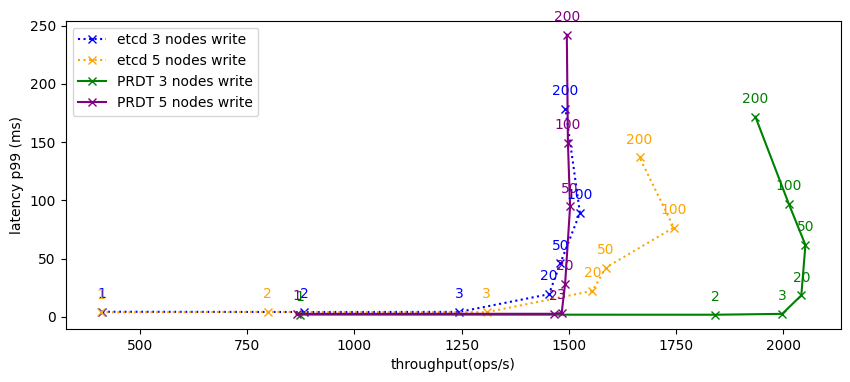

In [11]:
#plot_through_lat(filtered, 'pb', xlim=[0,2200], ylim=[0,320], suffix="write")
#plot_through_lat(filtered, 'etcd', xlim=[0,2200], ylim=[0,320], suffix="write")
plot_through_lat_both(filtered, suffix='write', xsize=10.0, ysize=4.0)

## Read Analysis

### prepare dataset

In [12]:
filtered = df[(df['kill_leader'] == 'undefined') & (df['geo_repl'] == False) & (df['workload'] == 'workloadb')]
filtered = filtered.sort_values('time').groupby(['nodes', 'threads', 'system']).tail(3) # take last three runs
aggregated = filtered.groupby(['system', 'threads', 'nodes']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean',  'update_p90(ms)': ['mean', 'var'], 'runtime(s)': 'mean', 'read_p99(ms)': 'mean', 'read_p90(ms)': 'mean', 'workload': ['first', 'count'], 'time': ['first', 'last']}).sort_values(['nodes', 'threads', 'system']).reset_index()
#filtered[['system', 'threads', 'workload', 'throughput(ops/s)', 'update_p99(ms)', 'read_p99(ms)', 'time']]
etcdframe = aggregated[aggregated['system'] == 'etcd']
pbframe = aggregated[(aggregated['system'] == 'pb')]
joined = pbframe.merge(etcdframe, on=['threads', 'nodes'], suffixes=['_pb', '_etcd'])
joined[['threads', 'nodes','workload_pb', 'workload_etcd', 'throughput(ops/s)_pb', 'throughput(ops/s)_etcd', 'read_p99(ms)_pb', 'read_p90(ms)_pb', 'read_p99(ms)_etcd', 'read_p90(ms)_etcd', 'update_p99(ms)_pb', 'update_p90(ms)_pb', 'update_p99(ms)_etcd', 'update_p90(ms)_etcd', 'time_pb', 'time_etcd']]

/tmp/ipykernel_389/897403841.py:7: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  joined = pbframe.merge(etcdframe, on=['threads', 'nodes'], suffixes=['_pb', '_etcd'])


threads nodes workload_pb       workload_etcd       throughput(ops/s)_pb  \
                       first count         first count                 mean   
0        1     3   workloadb     3     workloadb     3          1652.291369   
1        2     3   workloadb     3     workloadb     3          3300.105131   
2        3     3   workloadb     3     workloadb     3          4850.972860   
3       10     3   workloadb     3     workloadb     3         15609.059716   
4       20     3   workloadb     3     workloadb     3         16665.330494   
5       50     3   workloadb     3     workloadb     3         17906.676453   
6      100     3   workloadb     3     workloadb     3         17938.344527   
7      200     3   workloadb     3     workloadb     3         19012.903980   
8        1     5   workloadb     3     workloadb     3          1634.168075   
9        2     5   workloadb     3     workloadb     3          3278.689708   
10       3     5   workloadb     3     workloadb     3          4801.199864   
11      10     5   workloadb     3     workloadb     3         14361.880273   
12      20     5   workloadb     3     workloadb     3         15955.287227   
13      50     5   workloadb     3     workloadb     3         17093.143803   
14     100     5   workloadb     3     workloadb     3         17119.450837   
15     200     5   workloadb     3     workloadb     3         17455.469666   

   throughput(ops/s)_etcd read_p99(ms)_pb read_p90(ms)_pb read_p99(ms)_etcd  \
                     mean            mean            mean              mean   
0              800.432044           1.015        0.619667             1.833   
1             1502.716085           1.009        0.619667          2.584333   
2             1948.719389        1.088667           0.637             2.882   
3             5038.688108        0.987333        0.678333          4.071667   
4             7737.472141        2.304667        1.293333          5.738667   
5            12190.052038        7.306667           3.326         11.712667   
6            12323.176780          16.343           6.593         25.475667   
7            10766.041503       62.813667       13.186667         80.515667   
8              812.843800        1.057333           0.613          2.067333   
9             1518.641781        0.939667        0.624333          2.614667   
10            1933.427601        0.906667           0.634          2.888667   
11            5433.350240        1.033667           0.726          3.681333   
12            7509.218601        2.403333        1.355333          6.412333   
13           12063.853696           6.766        3.211333            11.868   
14           11898.998393       23.790333        6.168333         26.461667   
15           10297.129712          61.096       12.540333            93.242   

   read_p90(ms)_etcd update_p99(ms)_pb update_p90(ms)_pb              \
                mean              mean              mean         var   
0           1.314333              2.79          1.879667     0.00218   
1              1.493             3.011          1.745667     0.00869   
2           1.788333          2.781333          1.771333    0.008676   
3           2.769333              3.47          2.173333    0.005266   
4           3.496667         27.053667          5.237667     0.46297   
5              5.795              62.8         15.939667    30.18099   
6          11.839667         90.973333         24.599667  284.258056   
7          24.663333         86.316333            16.665  104.259493   
8           1.323667          3.351333             1.971    0.001228   
9                1.5              2.85          1.877333    0.002836   
10              1.74          3.242333             1.944    0.001516   
11          2.547667             4.745             2.706    0.005011   
12             3.462         32.812667          6.295667    0.472346   
13          5.855667         74.682667         24.557667    7.084658   
14   

### export tables

In [13]:
read_summary = joined[['nodes', 'threads', 'throughput(ops/s)_pb',  'throughput(ops/s)_etcd','read_p99(ms)_pb', 'read_p99(ms)_etcd']]
read_summary

,nodes,threads,throughput(ops/s)_pb,throughput(ops/s)_etcd,read_p99(ms)_pb,read_p99(ms)_etcd
,,,mean,mean,mean,mean
0,3,1,1652.291369,800.432044,1.015,1.833
1,3,2,3300.105131,1502.716085,1.009,2.584333
2,3,3,4850.972860,1948.719389,1.088667,2.882
3,3,10,15609.059716,5038.688108,0.987333,4.071667
4,3,20,16665.330494,7737.472141,2.304667,5.738667
5,3,50,17906.676453,12190.052038,7.306667,11.712667
6,3,100,17938.344527,12323.176780,16.343,25.475667
7,3,200,19012.903980,10766.041503,62.813667,80.515667
8,5,1,1634.168075,812.843800,1.057333,2.067333


In [14]:
print(read_summary.to_latex(index=False, float_format="%.2f"))

\begin{tabular}{rrrrrr}
\toprule
nodes & threads & throughput(ops/s)_pb & throughput(ops/s)_etcd & read_p99(ms)_pb & read_p99(ms)_etcd \\
 &  & mean & mean & mean & mean \\
\midrule
3 & 1 & 1652.29 & 800.43 & 1.01 & 1.83 \\
3 & 2 & 3300.11 & 1502.72 & 1.01 & 2.58 \\
3 & 3 & 4850.97 & 1948.72 & 1.09 & 2.88 \\
3 & 10 & 15609.06 & 5038.69 & 0.99 & 4.07 \\
3 & 20 & 16665.33 & 7737.47 & 2.30 & 5.74 \\
3 & 50 & 17906.68 & 12190.05 & 7.31 & 11.71 \\
3 & 100 & 17938.34 & 12323.18 & 16.34 & 25.48 \\
3 & 200 & 19012.90 & 10766.04 & 62.81 & 80.52 \\
5 & 1 & 1634.17 & 812.84 & 1.06 & 2.07 \\
5 & 2 & 3278.69 & 1518.64 & 0.94 & 2.61 \\
5 & 3 & 4801.20 & 1933.43 & 0.91 & 2.89 \\
5 & 10 & 14361.88 & 5433.35 & 1.03 & 3.68 \\
5 & 20 & 15955.29 & 7509.22 & 2.40 & 6.41 \\
5 & 50 & 17093.14 & 12063.85 & 6.77 & 11.87 \\
5 & 100 & 17119.45 & 11899.00 & 23.79 & 26.46 \\
5 & 200 & 17455.47 & 10297.13 & 61.10 & 93.24 \\
\bottomrule
\end{tabular}



### export plots

etcd 3 nodes
etcd 5 nodes
pb 3 nodes
pb 5 nodes


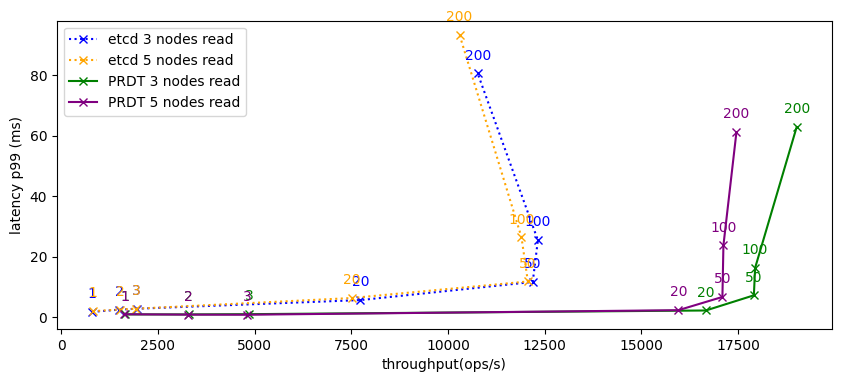

In [15]:
#plot_through_lat(filtered, 'pb', plotReads=True, plotWrites=False, xlim=[0,22000], ylim=[0,120], suffix='read')
#plot_through_lat(filtered, 'etcd',  plotReads=True, plotWrites=False, xlim=[0,22000], ylim=[0,120], suffix='read')
plot_through_lat_both(filtered,  plotReads=True, plotWrites=False, xsize=10.0, ysize=4.0, suffix='read')